# Video Game Sales Analysis
### Mini Project – Data Analysis and Visualization
#### Team Members
##### Aditya Gupta (251090051560)
##### Shubham Agarwal (251090051934)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Load datasets
vg    = pd.read_csv('Video Games.csv', encoding='latin1')
sales = pd.read_csv('Sales.csv', encoding='utf-16', sep='\t')

print('Video Games shape:', vg.shape)
print('Sales shape      :', sales.shape)
display(vg.head(3))
display(sales.head(3))

Video Games shape: (64016, 9)
Sales shape      : (64016, 6)


,Unique_ID,title,console,genre,publisher,developer,critic_score,release_date,last_update
0,1,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,17-09-2013,NaN
1,2,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,18-11-2014,03-01-2018
2,3,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,28-10-2002,NaN


,Unique_ID,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,1,20.32,6.37,0.99,9.85,3.12
1,2,19.39,6.06,0.60,9.71,3.02
2,3,16.15,8.41,0.47,5.49,1.78


In [64]:
# Merge both datasets on Unique_ID
df = pd.merge(vg, sales, on='Unique_ID', how='inner')
print('Merged shape:', df.shape)
display(df.head(3))

Merged shape: (64016, 14)


,Unique_ID,title,console,genre,publisher,developer,critic_score,release_date,last_update,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,1,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,17-09-2013,NaN,20.32,6.37,0.99,9.85,3.12
1,2,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,18-11-2014,03-01-2018,19.39,6.06,0.60,9.71,3.02
2,3,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,28-10-2002,NaN,16.15,8.41,0.47,5.49,1.78


In [65]:
# Check missing values
print(df.isnull().sum())

Unique_ID           0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
release_date     7051
last_update     46137
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
dtype: int64


In [66]:
# Data Cleaning & String Manipulation
df = df[df['total_sales'] > 0].copy()
df['developer']    = df['developer'].fillna('Unknown')
df['genre']        = df['genre'].str.strip().str.title()
df['console']      = df['console'].str.strip().str.upper()
df['release_year'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce').dt.year

print('Cleaned shape:', df.shape)
display(df[['title', 'console', 'genre', 'total_sales', 'release_year']].head(5))

Cleaned shape: (17570, 15)


,title,console,genre,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,16.15,2002.0
3,Grand Theft Auto V,X360,Action,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,15.09,2015.0


In [67]:
# Aggregation & Grouping
genre_sales   = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).reset_index()
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).head(15).reset_index()
pub_sales     = df.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).head(10)
region_totals = df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum()
yearly        = df.dropna(subset=['release_year']).groupby('release_year')['total_sales'].sum().reset_index()
yearly        = yearly[yearly['release_year'].between(1990, 2023)]
print ("Aggregations complete")

Aggregations complete


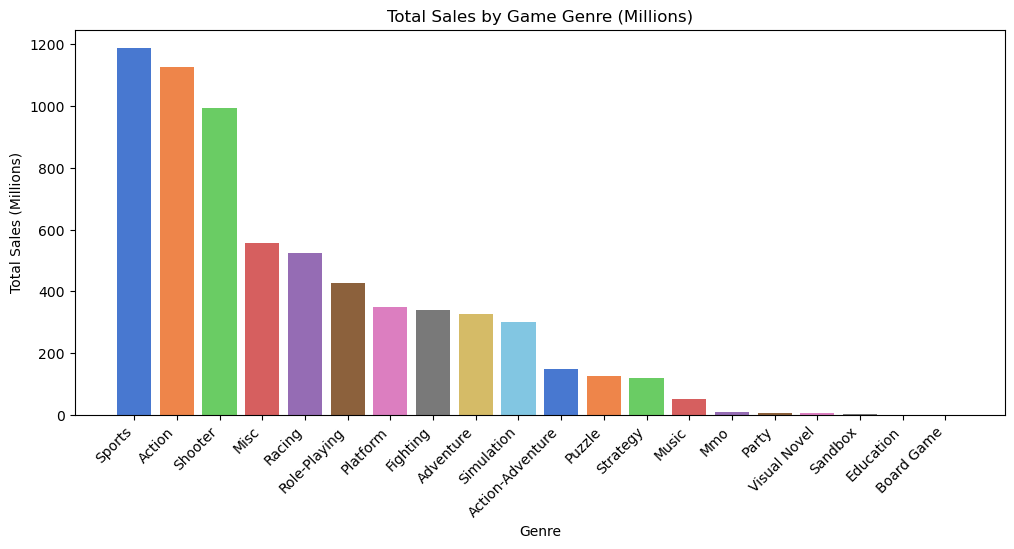

In [68]:
# Bar Chart - Total Sales by Genre
plt.figure(figsize=(12, 5))
plt.bar(genre_sales['genre'], genre_sales['total_sales'], color=sns.color_palette('muted', len(genre_sales)))
plt.title('Total Sales by Game Genre (Millions)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.show()

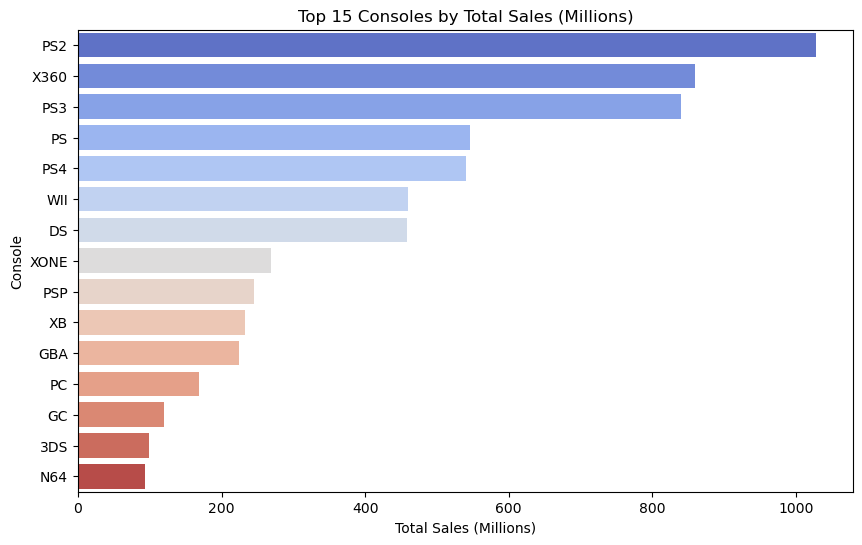

In [69]:
# Horizontal Bar Chart - Top 15 Consoles by Sales
plt.figure(figsize=(10, 6))
sns.barplot(data=console_sales, y='console', x='total_sales', palette='coolwarm')
plt.title('Top 15 Consoles by Total Sales (Millions)')
plt.xlabel('Total Sales (Millions)')
plt.ylabel('Console')
plt.show()

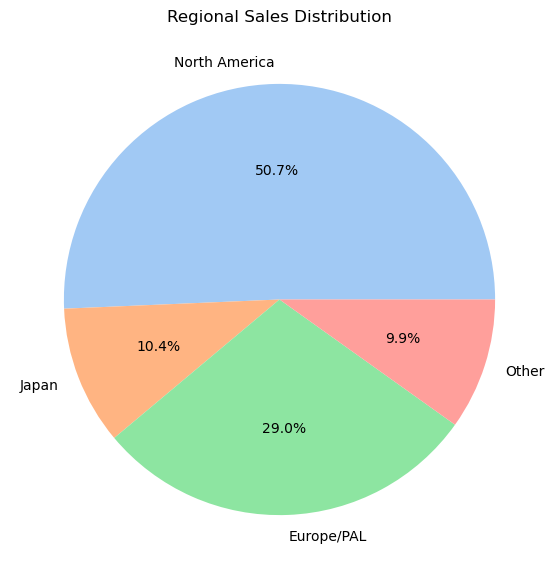

In [70]:
# Pie Chart - Regional Sales Distribution
labels = ['North America', 'Japan', 'Europe/PAL', 'Other']
plt.figure(figsize=(7, 7))
plt.pie(region_totals, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Regional Sales Distribution')
plt.show()

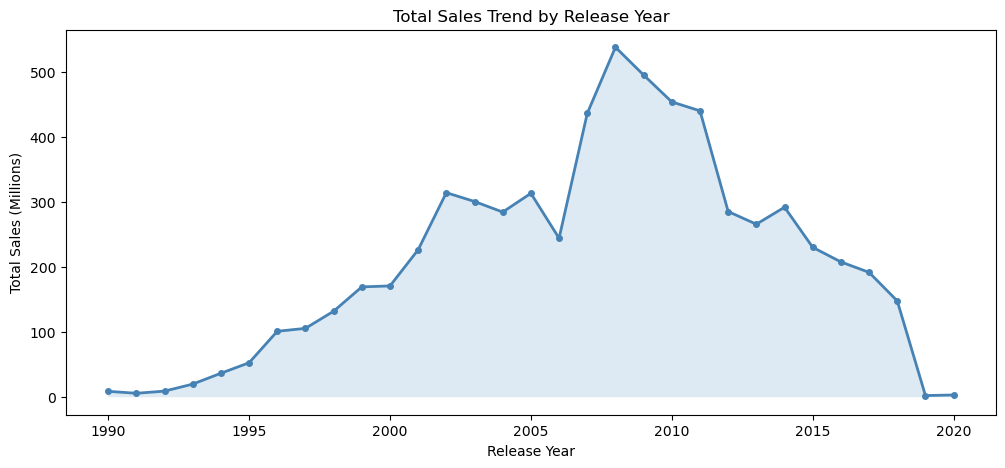

In [71]:
# 4.4 Line Chart - Yearly Sales Trend
plt.figure(figsize=(12, 5))
plt.plot(yearly['release_year'], yearly['total_sales'], marker='o', linewidth=2, color='steelblue', markersize=4)
plt.fill_between(yearly['release_year'], yearly['total_sales'], alpha=0.15)
plt.title('Total Sales Trend by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Total Sales (Millions)')
plt.show()

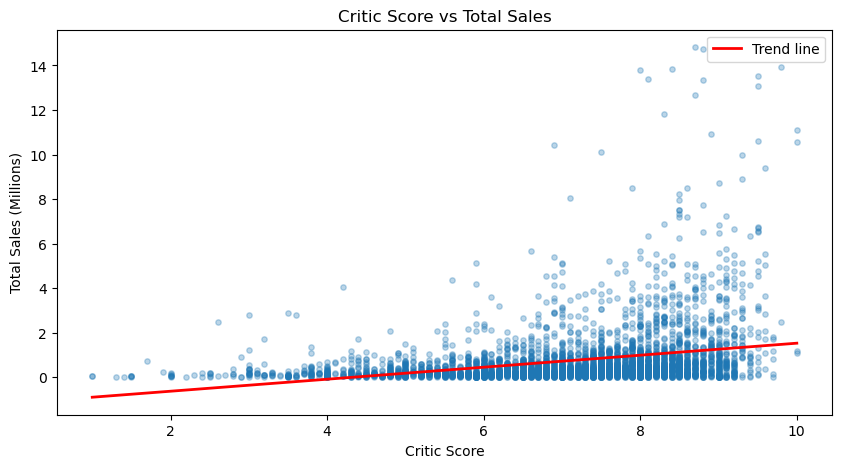

In [72]:
# Scatter Plot - Critic Score vs Total Sales
df_scores = df.dropna(subset=['critic_score'])
df_scores = df_scores[df_scores['total_sales'] <= 15]

m, b = np.polyfit(df_scores['critic_score'], df_scores['total_sales'], 1)
x_line = np.linspace(df_scores['critic_score'].min(), df_scores['critic_score'].max(), 100)

plt.figure(figsize=(10, 5))
plt.scatter(df_scores['critic_score'], df_scores['total_sales'], alpha=0.3, s=15)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend line')
plt.title('Critic Score vs Total Sales')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (Millions)')
plt.legend()
plt.show()

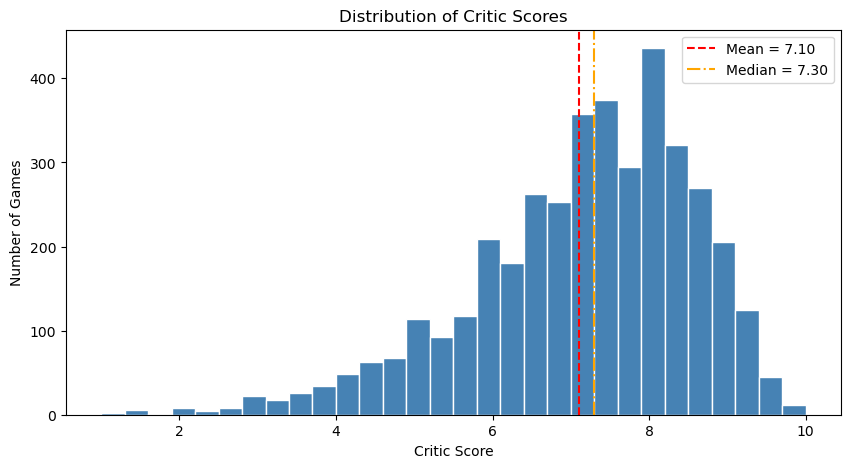

In [73]:
# Histogram - Distribution of Critic Scores
mean_score   = df_scores['critic_score'].mean()
median_score = df_scores['critic_score'].median()

plt.figure(figsize=(10, 5))
plt.hist(df_scores['critic_score'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_score,   color='red',    linestyle='--', label=f'Mean = {mean_score:.2f}')
plt.axvline(median_score, color='orange', linestyle='-.', label=f'Median = {median_score:.2f}')
plt.title('Distribution of Critic Scores')
plt.xlabel('Critic Score')
plt.ylabel('Number of Games')
plt.legend()
plt.show()

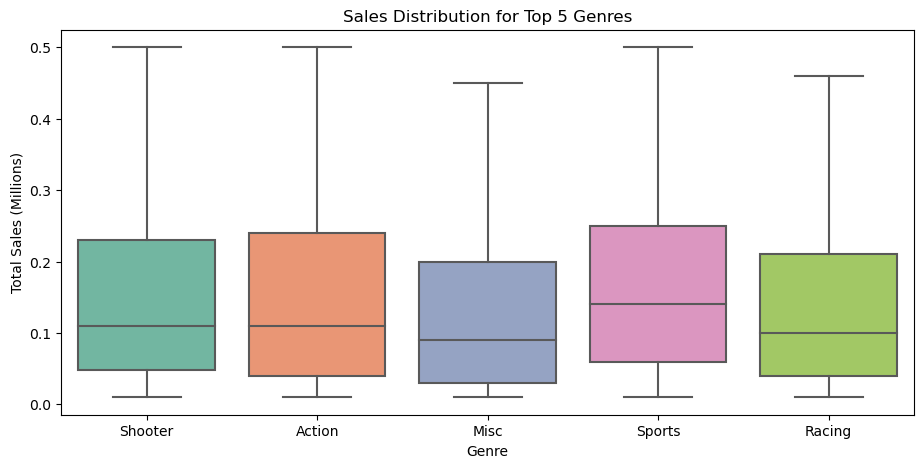

In [74]:
# Box Plot - Sales Distribution by Top 5 Genres
top5   = genre_sales.head(5)['genre'].tolist()
df_box = df[df['genre'].isin(top5) & (df['total_sales'] <= 0.5)]

plt.figure(figsize=(11, 5))
sns.boxplot(data=df_box, x='genre', y='total_sales', palette='Set2', flierprops=dict(marker=''))
plt.title('Sales Distribution for Top 5 Genres')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.show()

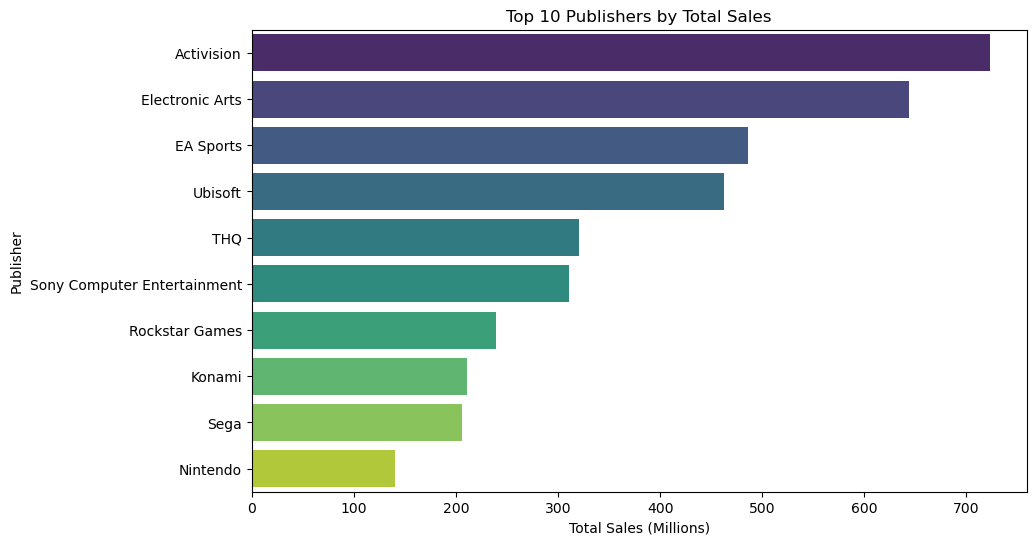

In [75]:
# Horizontal Bar Chart - Top 10 Publishers
plt.figure(figsize=(10, 6))
sns.barplot(x=pub_sales.values, y=pub_sales.index, palette='viridis')
plt.title('Top 10 Publishers by Total Sales')
plt.xlabel('Total Sales (Millions)')
plt.ylabel('Publisher')
plt.show()